# Análisis Exploratorio de Datos (EDA): Integridad Clínica y Atributos Cardiovasculares

# Introducción

El presente proyecto aborda el desafío de la clasificación supervisada en el sector de las telecomunicaciones, con el objetivo de predecir el riesgo de abandono de clientes (*churn*) a partir de indicadores demográficos, transaccionales y de uso de servicios. Dada la alta competitividad del ecosistema, donde factores como la ausencia de contratos a largo plazo o el tipo de soporte técnico adquirido facilitan la migración entre proveedores, la pérdida sistemática de usuarios representa un riesgo financiero crítico. Por lo tanto, el desarrollo de herramientas de detección temprana resulta indispensable para minimizar los falsos negativos, permitiendo identificar de manera oportuna a los perfiles en riesgo e implementar estrategias de retención proactivas que protejan los ingresos a largo plazo.

Para abordar esta complejidad, el trabajo se estructura bajo los principios de MLOps, garantizando un ciclo de vida predictivo robusto mediante el uso de algoritmos de ensamble basados en árboles de decisión (Random Forest, XGBoost, CatBoost y LightGBM). Si bien la naturaleza de estos modelos sacrifica la interpretabilidad inherente en favor de maximizar el rendimiento ante relaciones no lineales, este desafío se solventa estratégicamente mediante técnicas de Inteligencia Artificial Explicable (XAI). A través de la implementación de LIME (Local Interpretable Model-agnostic Explanations), el flujo de trabajo no solo asegura precisión estadística, sino que provee una operatividad transparente que revela cómo las interacciones de los datos influyen en cada predicción, habilitando así intervenciones comerciales fundamentadas e informadas.

:::{admonition} Nota Metodológica: Origen y Composición del Conjunto de Datos
:class: note

Para este proyecto se utiliza el conjunto de datos "Telco Customer Churn" [(BlastChar, 2019)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn), diseñado como un estándar analítico para predecir el comportamiento de abandono y estructurar programas focalizados de retención. El conjunto de datos consta de 7043 observaciones, donde cada registro representa el historial de un usuario individual.

La estructura de los atributos se divide en variables continuas y categóricas que capturan dimensiones operativas críticas del perfil del consumidor, incluyendo la demografía (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), la adopción de infraestructura y servicios de valor agregado (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`), y la consolidación de las condiciones de cuenta y facturación (`tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`).

El objetivo de clasificación se centra en la variable `Churn`, una clase binaria donde el valor $1$ indica que el cliente abandonó la compañía en el último mes y $0$ representa un estado de retención activa. Dada la granularidad de sus atributos transaccionales, este dataset ofrece una perspectiva comercial realista que fortalece la validez externa de los modelos desarrollados, permitiendo capturar la variabilidad inherente a los diferentes factores de riesgo como la falta de soporte técnico, la flexibilidad contractual y la sensibilidad a los costos.

:::

In [5]:
import sys
from pathlib import Path
import io
import os
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

def smart_format(x, fmt):
    """Safely format numeric values while preserving NaNs and strings."""
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "telco_churn.csv"

# Ensure src is in path
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

df = pd.read_csv(DATA_PATH, na_values=[' ', ''])

from eda_toolkit import *

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, chi2
from statsmodels.stats.multitest import multipletests
from IPython.display import HTML, display

def analyze_association_montecarlo(
    df: pd.DataFrame,
    target: str,
    feature_list: list[str],
    n_permutations: int = 9999,
    correction_method: str | None = "holm",
    spanish: bool = False,
    title: str | None = None,
    only_significant: bool = False,   # NUEVO PARÁMETRO
) -> None:
    """
    Monte Carlo permutation test for independence between categorical features 
    and a binary target.
    """

    def _significance_stars(p):
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

    _TABLE_STYLES = [
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                     ('color', 'black'), ('font-weight', 'bold'),
                                     ('border', '1px solid black'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                     ('padding', '10px')]},
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto')]}
    ]

    if df[target].nunique(dropna=True) < 2:
        print(f"[ERROR] Target '{target}' has less than 2 categories.")
        return

    raw_results = []
    skipped = []

    for col in feature_list:
        temp = df[[col, target]].dropna()

        if temp.empty:
            skipped.append(col)
            continue

        table = pd.crosstab(temp[col], temp[target])
        r, k = table.shape

        if r < 2 or k < 2:
            skipped.append(col)
            continue

        chi2_obs, _, dof, expected = chi2_contingency(table)
        crit_val = chi2.ppf(0.95, dof)

        target_array = temp[target].values
        col_array = temp[col].values
        greater_eq_count = 0

        for _ in range(n_permutations):
            shuffled_target = np.random.permutation(target_array)
            sim_table = pd.crosstab(col_array, shuffled_target)

            sim_table = sim_table.reindex(
                index=table.index,
                columns=table.columns,
                fill_value=0
            )

            sim_stat = np.sum((sim_table.values - expected) ** 2 / expected)

            if sim_stat >= chi2_obs:
                greater_eq_count += 1

        p_mc = (greater_eq_count + 1) / (n_permutations + 1)

        raw_results.append({
            "Feature": col,
            "Chi2_Obs": chi2_obs,
            "DF": int(dof),
            "Crit_Val": crit_val,
            "P_Raw": p_mc,
        })

    if not raw_results:
        print("[WARNING] No variables could be processed.")
        print(f"Skipped variables: {skipped}")
        return

    df_res = pd.DataFrame(raw_results)

    # Corrección por múltiples pruebas
    if correction_method:
        _, p_corr, _, _ = multipletests(df_res["P_Raw"], method=correction_method)
        df_res["P_Final"] = p_corr
    else:
        df_res["P_Final"] = df_res["P_Raw"]

    # =========================
    # FILTRO OPCIONAL
    # =========================
    if only_significant:
        df_res = df_res[df_res["P_Final"] < 0.05]

    # Formateo
    df_res["Chi-square Obs."] = df_res["Chi2_Obs"].map("{:.2f}".format)
    df_res["Critical Value"] = df_res["Crit_Val"].map("{:.2f}".format)

    df_res["p_format"] = df_res["P_Final"].apply(
        lambda p: f"< 0.001{_significance_stars(p)}"
        if p < 0.001
        else f"{p:.4f}{_significance_stars(p)}"
    )

    df_res = df_res.sort_values("P_Final", ascending=True)

    summary = df_res[
        ["Feature", "Chi-square Obs.", "DF", "Critical Value", "p_format"]
    ]

    if spanish:
        summary.columns = [
            "Variable",
            "Chi-cuadrado",
            "GL",
            "Valor Crítico",
            "p",
        ]
    else:
        summary.columns = ["Variable", "Chi-square", "DF", "Critical Value", "p"]

    styled = (
        summary.style
        .hide(axis="index")
        .set_table_styles(_TABLE_STYLES)
        .set_properties(
            subset=[summary.columns[0]],
            **{"text-align": "center", "font-weight": "bold"}
        )
    )

    html_title = f"<h3>{title}</h3>" if title else ""

    display(HTML(
        f"<div style='text-align: center;'>"
        f"{html_title}"
        + styled.to_html()
        + "</div>"
    ))

# Distribución de la Variable de Respuesta

Inicialmente, se estudia la distribución de la variable objetivo (`Churn`), la cual constituye el eje central de la estrategia de evaluación en este modelo de predicción de abandono de clientes. Este indicador binario clasifica el estado del usuario en dos categorías: 0 para clientes que permanecieron activos con el servicio y 1 para aquellos que cancelaron su suscripción durante el último mes. Comprender el balance entre estas clases es un paso fundamental en el análisis exploratorio, ya que permite caracterizar la prevalencia del evento de interés dentro del conjunto de datos y establecer una base sólida para las comparaciones bivariadas subsiguientes.

El siguiente gráfico ilustra la distribución de la variable en el conjunto de datos:


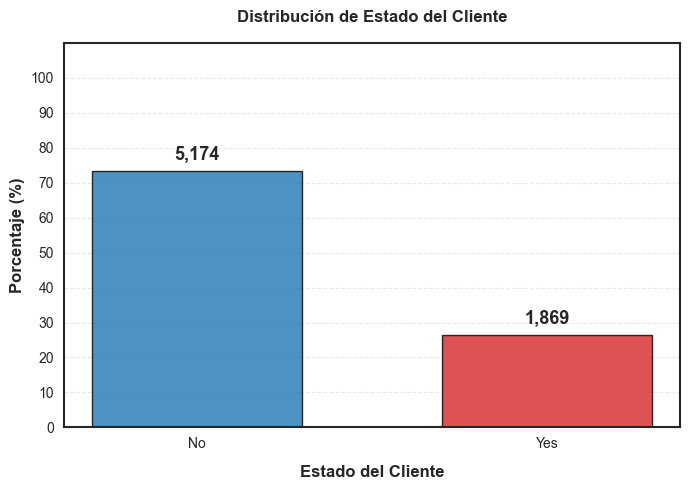

In [7]:
plot_categorical_distribution(
    df, column='Churn', 
    display_name='Estado del Cliente',
    level_mapping={0: 'Permaneció (0)', 1: 'Abandonó (1)'},
    title="Distribución de Estado del Cliente", ylabel="Porcentaje (%)"
)

Tal como se observa en la figura, existe una distribución moderadamente desbalanceada entre ambas clases, con una predominancia de clientes que permanecen activos (73.46%) frente a aquellos que efectivamente abandonaron el servicio (26.54%). A diferencia de escenarios con un desbalance extremo, esta proporción permite que el modelo capture los patrones discriminantes de la clase minoritaria de forma natural, aunque exige una selección rigurosa de métricas que prioricen la detección del evento de interés.

Desde una perspectiva de negocio, esta asimetría refleja fielmente la realidad operativa de las telecomunicaciones, donde el abandono es un evento menos frecuente pero de alto impacto financiero. Contar con un volumen robusto de casos positivos facilita el entrenamiento del sistema para identificar perfiles de riesgo, lo cual es fundamental para optimizar las estrategias de retención y minimizar el costo por pérdida de clientes. En consecuencia, esta estructura proporciona un entorno adecuado para obtener una evaluación estable, permitiendo que las métricas de clasificación reflejen con mayor fidelidad la capacidad del modelo para predecir el comportamiento del usuario en condiciones reales de mercado.

# Arquitectura del Conjunto de Datos

Una vez analizada la variable objetivo, es imperativo examinar la arquitectura del conjunto de datos para garantizar la integridad de la información y la validez de los resultados predictivos. En esta etapa, se evalúa la calidad de los atributos mediante la identificación de valores nulos y la verificación de la consistencia en los tipos de datos, lo cual permite distinguir entre variables con alta fidelidad informativa y aquellas cuya representatividad podría verse comprometida por la ausencia de registros.

Este diagnóstico facilita la caracterización técnica de los atributos, estableciendo la base del preprocesamiento al diferenciar claramente entre variables numéricas y categóricas. Dicha distinción es fundamental para estructurar un flujo de procesamiento coherente, definiendo estrategias específicas de escalamiento, codificación y tratamiento de datos faltantes que eviten inconsistencias en las etapas posteriores del pipeline. La siguiente tabla resume las variables presentes en el dataset junto a su tipificación técnica:

In [8]:
column_types = df.dtypes
type_groups = {}

for col_name, dtype in column_types.items():
    type_groups[str(dtype)] = type_groups.get(str(dtype), []) + [col_name]

resumen_tipos = pd.DataFrame([
    {
        'Tipo de Dato': t, 
        'Cantidad': len(cols), 
        'Variables': ", ".join(cols)
    } 
    for t, cols in type_groups.items()
])

format_dict_tipos = {
    "Cantidad": lambda x: smart_format(x, "{:,.0f}")
}

styled_types = resumen_tipos.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                 ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                   ('color', 'black'), ('font-weight', 'bold'),
                                   ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                   ('padding', '10px')]}
])

styled_types = styled_types.set_properties(subset=['Tipo de Dato', 'Cantidad'], **{'text-align': 'center'})
styled_types = styled_types.set_properties(subset=['Variables'], **{'text-align': 'left'})
styled_types = styled_types.format(format_dict_tipos)
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_types.to_html() + "</div>"))

Tipo de Dato,Cantidad,Variables
object,17,"customerID, gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, Churn"
int64,2,"SeniorCitizen, tenure"
float64,2,"MonthlyCharges, TotalCharges"


El conjunto de datos presenta una arquitectura mixta de 7,043 observaciones, integrando dimensiones demográficas y operativas en una estructura de 18 variables de tipo objeto, 2 de tipo entero (`int64`) y 1 de tipo flotante (`float64`). Un examen inicial permitió identificar que la variable `TotalCharges`, la cual se cargó originalmente como tipo objeto, es en realidad de naturaleza continua. Esta distinción es crítica para garantizar un tratamiento estadístico coherente con el significado financiero de la columna.

Por otro lado, el análisis de integridad mediante el mapa de densidad de información (*missingness map*) reveló la presencia de valores faltantes localizados exclusivamente en la columna `TotalCharges`. Estos vacíos, que representan 11 observaciones (equivalentes al 0.156% del total), se hicieron visibles tras la conversión de la variable a formato numérico.


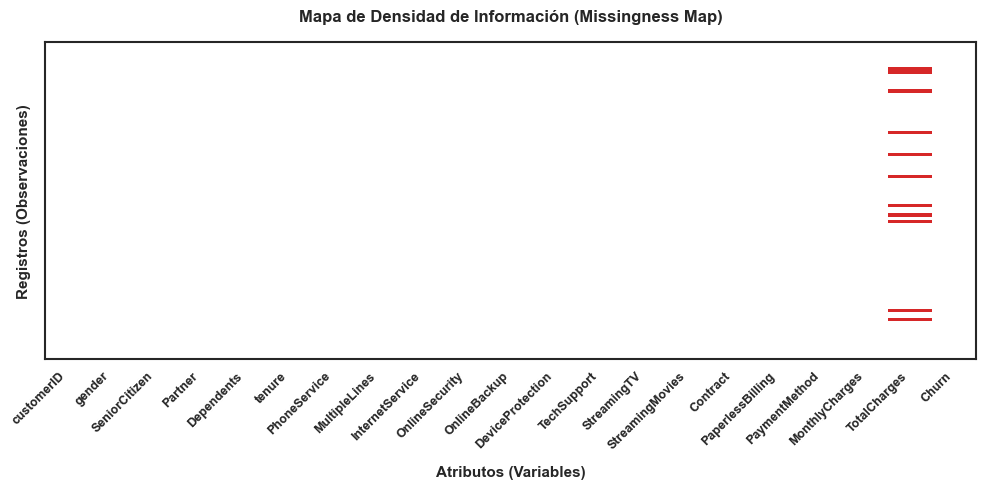

In [9]:
df_nulos = df[df['TotalCharges'].isnull()]
df_limpios = df[df['TotalCharges'].notnull()].sample(89, random_state=42)
df_representativo = pd.concat([df_nulos, df_limpios]).sample(frac=1, random_state=42)
plot_missingness_map(df_representativo, title = 'Mapa de Densidad de Información (Missingness Map)',
                    xlabel= 'Atributos (Variables)', ylabel = 'Registros (Observaciones)')

A partir de estos hallazgos, se considera necesario profundizar en el estudio detallado de las variables numéricas del conjunto de datos, con el fin de comprender su comportamiento estadístico, distribución y posibles anomalías. Este análisis permitirá, en una etapa posterior, abordar de manera fundamentada la naturaleza de los datos faltantes, evaluando si su ausencia responde a patrones sistemáticos o aleatorios, lo cual es clave para definir una estrategia adecuada de imputación o tratamiento.

# Análisis Univariado

En esta etapa se examina la distribución de probabilidad de las variables continuas con el objetivo de identificar posibles datos atípicos y evaluar desviaciones respecto a la distribución gaussiana. Para ello, se utilizan diagramas de cajas y análisis de densidad que permiten caracterizar la dispersión y los comportamientos extremos en el conjunto de datos. Es importante precisar que, dado que el proyecto se limita al uso de modelos basados en árboles (`Random Forest`, `XGBoost`, `CatBoost` y `LightGBM`), el cumplimiento de supuestos distribucionales no constituye el eje central del análisis, sino que se emplea como una herramienta diagnóstica para identificar irregularidades estructurales.

El propósito de este diagnóstico es estrictamente analítico y preventivo, centrándose en la detección de datos faltantes enmascarados por la codificación del dataset. Solo en aquellos casos donde exista evidencia de errores de registro o presencia de valores de relleno (*placeholders*) que carezcan de lógica operativa, los registros serán marcados como valores ausentes (*NA*) para su posterior imputación. De este modo, se garantiza que cualquier ajuste dentro del flujo de MLOps responda a la corrección de inconsistencias técnicas y no a una manipulación de la variabilidad del comportamiento del usuario, preservando la integridad de las señales operativas que el modelo deberá capturar.

## Cargos Mensuales

Los Cargos Mensuales (`MonthlyCharges`) constituyen una de las variables transaccionales de mayor relevancia en el análisis del comportamiento de abandono. Representa el costo recurrente facturado a los usuarios por el conjunto de servicios suscritos y actúa como un indicador directo del nivel de compromiso financiero del cliente, así como de su sensibilidad al precio en un entorno competitivo. A continuación, se presentan dos figuras que detallan la morfología de esta variable en la muestra:


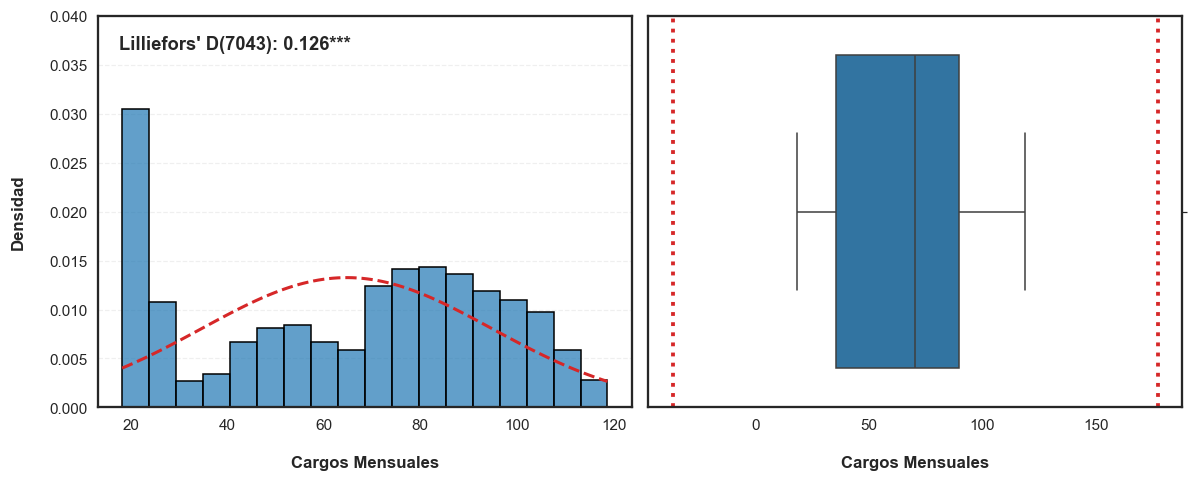

In [10]:
plot_numeric_diagnostics(df, "MonthlyCharges", "Cargos Mensuales", show_qq=False, spanish=True, ylim = (0,0.04))

En términos morfológicos, la variable presenta una distribución multimodal, con una acumulación de registros en los valores mínimos y una densidad sostenida en el rango de $70$ a $100$ dólares estadounidenses. Este patrón es consistente con la presencia de distintos niveles de servicio dentro del conjunto de datos y no evidencia irregularidades en la forma de la distribución. Asimismo, la dispersión observada no sugiere la existencia de valores atípicos que requieran tratamiento o exclusión.

La concentración de observaciones cerca del valor mínimo de $18.25$ no corresponde a errores de registro ni a valores artificiales. La variación en los decimales indica que estos valores reflejan precios reales, posiblemente asociados a planes básicos. Dado que no se identifican inconsistencias en estos registros, se considera adecuado mantenerlos en el dataset, ya que representan condiciones válidas del negocio y aportan información relevante sobre los segmentos de menor costo.

## Cargos Totales

Los Cargos Totales (`TotalCharges`) representan el monto acumulado facturado al cliente desde el inicio de su relación con la compañía. Esta variable constituye un indicador crítico del valor de vida del cliente (*Customer Lifetime Value*) y permite capturar la magnitud del impacto económico que supondría su abandono. A continuación, se presentan las figuras que detallan la morfología de esta variable en la muestra:


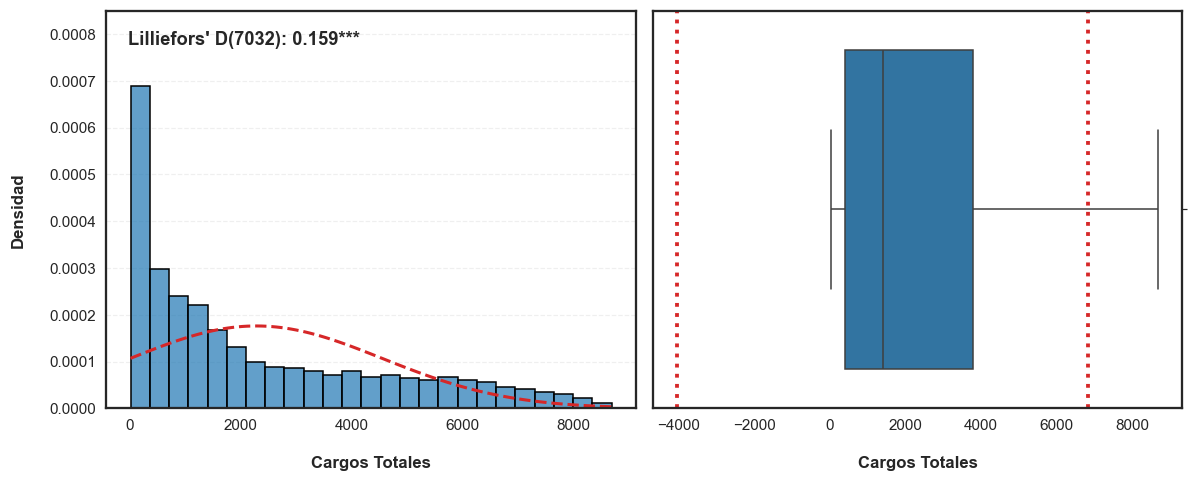

In [11]:
plot_numeric_diagnostics(df, "TotalCharges", "Cargos Totales", show_qq=False, spanish=True, ylim=(0, 0.00085))

En términos morfológicos, los Cargos Totales (`TotalCharges`) presentan un rango empírico de 18.80 a 8,684.80 dólares, con una estructura que resulta plenamente coherente con la acumulación de los cargos mensuales a lo largo del tiempo de permanencia de los usuarios. Este análisis se realiza sobre las 7,032 observaciones validadas tras la gestión de las 11 inconsistencias iniciales, lo cual confirma que la progresión de los valores refleja la trayectoria financiera real de la base de clientes y no errores en la captura de los datos.

La distribución exhibe un marcado sesgo positivo con una cola extendida hacia los niveles de mayor facturación acumulada. Si bien el filtro de Hampel identifica ciertas observaciones en el extremo superior, este comportamiento es atribuible a la propia naturaleza de la distribución de larga cola y no a la presencia de valores atípicos genuinos. En consecuencia, no se encuentra evidencia de datos faltantes o ruidos adicionales, validando esta variable como un indicador íntegro y relevante para caracterizar el compromiso económico de los usuarios en el modelo de clasificación.

## Síntesis y Resumen Descriptivo

Tras concluir el análisis de las variables cuantitativas, se obtiene una visión general de la integridad del dataset. Aunque inicialmente no se detectaron valores nulos, una revisión más detallada evidenció que la variable `TotalCharges`presenta datos faltantes. Sin embargo, estos representan solo el 0.156% del total, por lo que no suponen un problema estructural ni comprometen el modelado, especialmente considerando que los modelos basados en árboles pueden gestionarlos de forma interna.

Dado el reducido número de observaciones implicadas, el análisis comienza con una inspección directa de estos casos dentro del dataset, con el objetivo de identificar posibles patrones o características distintivas. A partir de esta exploración inicial, se evalúa el mecanismo de generación de los valores faltantes para determinar si su ocurrencia es completamente aleatoria (MCAR) o responde a algún patrón sistemático (MAR). Para ello, se emplean pruebas de independencia basadas en simulaciones de Monte Carlo, utilizando contrastes con p-valores simulados para variables categóricas y la prueba U de Mann-Whitney para comparar las distribuciones en variables numéricas entre registros con y sin datos faltantes.

In [12]:
from IPython.display import HTML

df_missing_analysis = df.copy()
df_missing_analysis['TotalCharges_Missing'] = df_missing_analysis['TotalCharges'].isna().astype(int)
cols_interes = ['Dependents', 'Contract', 'MonthlyCharges', 'tenure']

missing_obs = df_missing_analysis[df_missing_analysis['TotalCharges_Missing'] == 1][cols_interes]

styled_missing = (
    missing_obs
    .style
    .hide(axis='index')
    .set_table_styles([
        {'selector': '', 'props': [
            ('margin-left', 'auto'),
            ('margin-right', 'auto'),
            ('width', '80%'),
            ('border-collapse', 'collapse')
        ]},
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#f2f2f2'),
            ('color', 'black'),
            ('font-weight', 'bold'),
            ('border', '1px solid black'),
            ('padding', '10px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('border', '1px solid black'),
            ('padding', '8px')
        ]}
    ])
)

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_missing.to_html() + "</div>"))

Dependents,Contract,MonthlyCharges,tenure
Yes,Two year,52.550000,0
Yes,Two year,20.250000,0
Yes,Two year,80.850000,0
Yes,Two year,25.750000,0
Yes,Two year,56.050000,0
Yes,Two year,19.850000,0
Yes,Two year,25.350000,0
Yes,Two year,20.000000,0
Yes,One year,19.700000,0
Yes,Two year,73.350000,0


In [36]:
df_missing_analysis = df.copy()
df_missing_analysis['TotalCharges_Missing'] = df_missing_analysis['TotalCharges'].isna().astype(int)

cat_vars = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

analyze_association_montecarlo(
    df=df_missing_analysis, 
    target='TotalCharges_Missing', 
    feature_list=cat_vars, 
    n_permutations=2000,        
    correction_method='holm',    
    spanish=True, only_significant = True
)

Variable,Chi-cuadrado,GL,Valor Crítico,p
Dependents,22.52,1,3.84,0.0085**
Contract,27.25,2,5.99,0.0085**
PaymentMethod,16.53,3,7.81,0.0375*


Los resultados del análisis de asociación mediante $\chi^2$ y V de Cramér evidencian una dependencia sistemática entre la omisión de registros en Cholesterol y el perfil clínico de los pacientes. En particular, las variables `FastingBS` y `HeartDisease` presentan una asociación de tamaño mediano ($V = 0.32$, $p < 0.001$), lo que sugiere que la probabilidad de encontrar un valor faltante es significativamente mayor en pacientes con glucemia elevada o con un diagnóstico positivo de enfermedad cardíaca. Este hallazgo es consistente con un mecanismo de datos faltantes en el azar (MAR, Missing At Random), donde la "incompletitud" del dato está condicionada por otras variables observadas en el dataset.

Desde una perspectiva metodológica, la presencia de estas asociaciones significativas invalida el uso de técnicas de imputación simple (como el reemplazo por la media o mediana), ya que estas ignorarían la estructura de correlación identificada y podrían introducir sesgos artificiales en las distribuciones. Por el contrario, la evidencia de un mecanismo MAR robustece la necesidad de implementar algoritmos de imputación multivariada —como MICE o IterativeImputer— que sean capaces de reconstruir los valores de colesterol aprovechando la información predictiva presente en el resto de los atributos clínicos, preservando así la integridad estocástica necesaria para el entrenamiento de los modelos de clasificación.

Análisis más detallados de la distribución por grupo revelan que la falta de registros de colesterol se concentra de manera desproporcionada en los perfiles de mayor riesgo clínico. Mientras que en pacientes con glucemia normal la omisión es marginal, en el grupo con Glucemia Elevada (>120 mg/dl) el dato falta en el 41.7% de los sujetos (89 de 214). Esta asimetría se replica en el diagnóstico principal: en el grupo con Presencia de EC, el nulo afecta a 152 personas (casi el 30% del nivel), frente a solo 20 casos detectados en el grupo sano. La evidencia visual confirma que el perfil lipídico dejó de registrarse sistemáticamente en los pacientes con comorbilidades metabólicas y diagnóstico positivo, dejando un vacío de información precisamente donde el marcador de colesterol es más crítico para la caracterización del riesgo cardiovascular.

In [4]:
df_missing_analysis = df.copy()
df_missing_analysis['TotalCharges_Missing'] = df_missing_analysis['TotalCharges'].isna().astype(int)

# 2. Generar la tabla de contingencia
# Usamos map para que las etiquetas en la tabla sean descriptivas
contingency_table = pd.crosstab(
    df_missing_analysis['tenure'], 
    df_missing_analysis['TotalCharges_Missing'],
    margins=True,       # Añade los totales (All)
    margins_name="Total"
)

# 3. Mostrar la tabla con un estilo limpio
print("Tabla de Contingencia: Dependents vs TotalCharges_Missing")
print("-" * 60)
display(contingency_table)

# 4. Verificación rápida de la regla de oro (frecuencia < 5)
min_val = contingency_table.iloc[:-1, :-1].values.min()
print("-" * 60)
print(f"Frecuencia mínima observada en celdas: {min_val}")
if min_val < 5:
    print("Aviso: Se confirma la necesidad de usar Monte Carlo o Fisher.")
else:
    print("Nota: Las frecuencias cumplen con el criterio mínimo de 5.")

Tabla de Contingencia: Dependents vs TotalCharges_Missing
------------------------------------------------------------


TotalCharges_Missing,0,1,Total
tenure,,,
0,0,11,11
1,613,0,613
2,238,0,238
3,200,0,200
4,176,0,176
...,...,...,...
69,95,0,95
70,119,0,119
71,170,0,170


------------------------------------------------------------
Frecuencia mínima observada en celdas: 0
Aviso: Se confirma la necesidad de usar Monte Carlo o Fisher.


Similarmente, la desagregación por diagnóstico clínico ratifica que el vacío de información lipídica se concentra en la población de mayor riesgo. Como se observa en la gráfica, mientras que en pacientes con Ausencia de EC la omisión del registro es marginal (solo 20 casos), en el grupo con Presencia de EC la proporción de datos faltantes se dispara significativamente, afectando a 152 pacientes (casi el 30% del nivel). Esta marcada asimetría confirma que el perfil lipídico dejó de registrarse sistemáticamente en los pacientes con diagnóstico positivo, dejando un vacío de información precisamente donde el marcador de colesterol es más crítico para la caracterización del riesgo cardiovascular.

Al evaluar las variables numéricas mediante la prueba U de Mann-Whitney, se observa que la mayoría de los atributos presentan tamaños de efecto despreciables ($r < 0.1$), lo que inicialmente sugeriría un comportamiento cercano a la aleatoriedad. No obstante, las variables `MaxHR` ($r = 0.27$, $p < 0.001$) y `Age` ($p < 0.001$) muestran diferencias estadísticamente significativas que no deben ignorarse.

Específicamente, el grupo con datos ausentes de colesterol tiende a ser mayor (mediana de 57.5 años frente a 54.0) y a presentar una frecuencia cardíaca máxima significativamente menor (120 bpm frente a 140 bpm). Clínicamente, una MaxHR baja suele estar asociada a una menor reserva cronotrópica o a una mayor severidad del cuadro cardiovascular. Este hallazgo refuerza la tendencia observada en las variables categóricas: los datos faltantes no se distribuyen uniformemente, sino que se concentran en pacientes con un perfil clínico ligeramente más envejecido y con indicadores de mayor compromiso funcional. Aunque el efecto es pequeño según Rosenthal, la convergencia de estas diferencias con el diagnóstico de enfermedad cardíaca confirma que el mecanismo de pérdida está anclado a la gravedad del paciente.

In [35]:
numeric_cols = ['MonthlyCharges', 'tenure']
analyze_continuous_association(df = df_missing_analysis, target = 'TotalCharges_Missing', numeric_features = numeric_cols,
    correction_method = "holm", spanish = True, group_names = ("Presente", "Faltante")) 

Variable,Presente,Faltante,Homoced.,U,r,Efecto
tenure,29.0 (46.0),0.0 (0.0),No,77352.00***,0.07,Despreciable
MonthlyCharges,70.3 (54.3),25.8 (38.8),Sí,55561.00*,0.03,Despreciable


En general, el diagnóstico de los mecanismos de ausencia revela que la falta de información en la variable Cholesterol no es un fenómeno aleatorio, sino un evento sistemático vinculado a la severidad del cuadro clínico del paciente. La convergencia de una asociación mediana con el diagnóstico de `HeartDisease` y la Glucemia Elevada, sumada a las diferencias significativas en la `MaxHR` y la Edad, confirma un mecanismo de datos faltantes en el azar (MAR). Los perfiles con mayor compromiso cardiovascular y metabólico son precisamente los que presentan una mayor tasa de omisión, lo que invalida cualquier técnica de imputación simple que ignore estas correlaciones. En consecuencia, la integridad del análisis posterior depende de una estrategia de imputación multivariada que sea capaz de reconstruir el perfil lipídico aprovechando la estructura de dependencia identificada, asegurando que no se subestime el riesgo en la subpoblación más vulnerable del dataset.

Para concluir la caracterización detallada de las dimensiones cuantitativas, se presenta una síntesis estadística que consolida el comportamiento de la muestra. Esta sección de cierre integra una tabla de estadísticos descriptivos que permite visualizar, de manera conjunta, la tendencia central, la variabilidad y los rangos de cada atributo. Dicho resumen no solo sirve como una referencia técnica de la "anatomía" de los datos, sino que actúa como el punto de validación final para confirmar que la base de datos es robusta y coherente antes de iniciar la exploración de los perfiles categóricos y la prevalencia de la patología en el dataset.

In [14]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Validación rápida post-imputación
print(f"Valores nulos restantes en TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(df[df['tenure'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Valores nulos restantes en TotalCharges: 0
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           0.0
753        0           20.25           0.0
936        0           80.85           0.0
1082       0           25.75           0.0
1340       0           56.05           0.0


In [41]:
numeric_cols = ['MonthlyCharges', 'TotalCharges']
plot_descriptive_summary(df, numeric_cols, spanish = True)

Variable,Media (SD),Mediana (IQR),Mínimo,Máximo,Asimetría,Curtosis
MonthlyCharges,64.76 (30.09),70.35 (54.35),18.25,118.75,-0.22,-1.26
TotalCharges,2283.30 (2266.77),1397.47 (3393.29),18.80,8684.80,0.96,-0.23


Al consolidar el análisis cuantitativo, se observa una clara concordancia entre la inspección visual y los coeficientes de forma. Las variables de Edad, Presión Arterial (`RestingBP`) y Frecuencia Cardíaca Máxima (`MaxHR`) destacan por presentar los niveles más bajos de asimetría y curtosis, ratificándose como las dimensiones más simétricas y estables del dataset. Este equilibrio estadístico facilita su posterior modelado y contrasta con la marcada distorsión de `Oldpeak`, cuya asimetría extrema es un reflejo fiel de la naturaleza clínica del marcador isquémico. Con esta validación final de los descriptores de tendencia central y dispersión, se cierra la fase numérica asegurando una base sólida para la transición hacia el análisis de las variables categóricas.

# Análisis Bivariado

## Relación entre Variables Categóricas y la Variable Objetivo

Habiendo consolidado el perfil cuantitativo de la muestra, esta sección aborda la Relación entre Variables Categóricas y la Variable Objetivo. Si bien la descripción individual de estos atributos se omitió en las etapas iniciales en aras de la brevedad, ahora se retoman para identificar los patrones clínicos más determinantes. Para orientar este análisis y evitar una exploración redundante, se ejecutaron múltiples pruebas de independencia Chi-cuadrado de Pearson como filtro preliminar. El criterio rector para seleccionar qué variables presentar no fue únicamente su significancia estadística, sino la magnitud de su tamaño del efecto (V de Cramér). En consecuencia, la caracterización visual y clínica que se desarrolla a continuación se concentra de manera exclusiva en aquellas características que demostraron un poder discriminativo sustancial, priorizando estrictamente las asociaciones clasificadas con un efecto mediano o grande sobre la presencia de la enfermedad cardíaca.

In [38]:
cat_vars = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

analyze_chi2_association(df, target = 'Churn', feature_list = cat_vars, spanish=True)

Variable,Chi-cuadrado,GL,Valor Crítico,V de Cramér,Efecto
Contract,1184.60***,2,5.99,0.41,Mediano
OnlineSecurity,850.00***,2,5.99,0.35,Mediano
TechSupport,828.20***,2,5.99,0.34,Mediano
InternetService,732.31***,2,5.99,0.32,Mediano
PaymentMethod,648.14***,3,7.81,0.30,Mediano
OnlineBackup,601.81***,2,5.99,0.29,Pequeño
DeviceProtection,558.42***,2,5.99,0.28,Pequeño
StreamingTV,374.20***,2,5.99,0.23,Pequeño
StreamingMovies,375.66***,2,5.99,0.23,Pequeño
PaperlessBilling,258.28***,1,3.84,0.19,Pequeño


El análisis de asociación revela una jerarquía predictiva clara, destacando el protagonismo de las variables categóricas con tamaños de efecto grande y mediano. Los atributos con mayor capacidad discriminativa son la morfología de la pendiente del segmento ST (`ST_Slope`, $V = 0.62$) y el tipo de dolor torácico (`ChestPainType`, $V = 0.54$), los cuales exhiben un efecto de magnitud grande y se consolidan como los marcadores clínicos más robustos de la patología. En un segundo nivel de relevancia, pero manteniendo un impacto predictivo sustancial (efecto mediano), se encuentran la presencia de angina inducida por el esfuerzo (`ExerciseAngina`, $V = 0.49$) y el sexo del paciente (`Sex`, $V = 0.31$), factores que complementan el perfil de riesgo del paciente bajo estrés cardiovascular y consideraciones epidemiológicas.

Por el contrario, los factores restantes demostraron un poder de asociación menor y no serán el foco principal de la exploración visual. La glucemia en ayunas (`FastingBS`, $V = 0.27$) refleja un tamaño de efecto pequeño, mientras que la lectura del electrocardiograma en reposo (`RestingECG`, $V = 0.08$) presenta una asociación clínicamente despreciable frente a la variable objetivo; esto indica que, aunque puedan aportar contexto sistémico, su capacidad para discriminar la presencia de la enfermedad de forma aislada se considera, a priori, limitada.

:::{admonition} Nota Metodológica: Tamaño del Efecto y V de Cramer
:class: note

Para cuantificar la fuerza de la asociación entre las variables categóricas y la presencia de enfermedad cardíaca, se utiliza el coeficiente V de Cramer. A diferencia del valor $p$, que solo indica la existencia de una relación estadísticamente significativa, este estadístico permite normalizar el resultado de la prueba $\chi^2$ para que sea comparable entre tablas de diferentes dimensiones.

La fórmula matemática para su cálculo es:

$$V = \sqrt{\frac{\chi^2}{n \cdot \min(k-1, r-1)}}$$

Donde:

* $\chi^2:$ Es el estadístico obtenido en la prueba de Pearson.
* $n:$ Es el tamaño total de la muestra.
* $k$ y $r:$ Representan el número de columnas y filas en la tabla de contingencia, respectivamente.

Siguiendo los criterios de [Cohen (2013)](https://doi.org/10.4324/9780203771587), la interpretación del tamaño del efecto se rige por la magnitud del coeficiente, donde valores cercanos a $0$ indican una asociación despreciable y valores cercanos a $1$ una asociación perfecta. En este análisis, se adoptan los umbrales estándar para ciencias del comportamiento: Pequeño ($\approx 0.10$), Mediano ($\approx 0.30$) y Grande ($\geq 0.50$).

:::

La distribución de la Pendiente del Segmento ST (`ST_Slope`), la variable con mayor fuerza de asociación en el análisis, revela un patrón de riesgo fuertemente segmentado. La prevalencia intragrupo muestra que los pacientes con una pendiente horizontal o descendente presentan una incidencia de enfermedad cardíaca cercana al 80%. Este comportamiento concuerda de manera estricta con la expectativa clínica estándar, ya que ambas alteraciones morfológicas en un electrocardiograma de esfuerzo son signos directos de isquemia, evidenciando dificultades en la recuperación eléctrica del ventrículo. Por el contrario, la pendiente ascendente representa la adaptación fisiológica normal de un corazón sano ante el aumento de la demanda metabólica, lo cual se corrobora en los datos al observar que aproximadamente el 80% de los individuos de esta categoría están libres de la patología. Esta marcada polarización empírica entre la respuesta sana y la isquémica explica por qué esta medición constituye el predictor categórico más robusto para la clasificación.


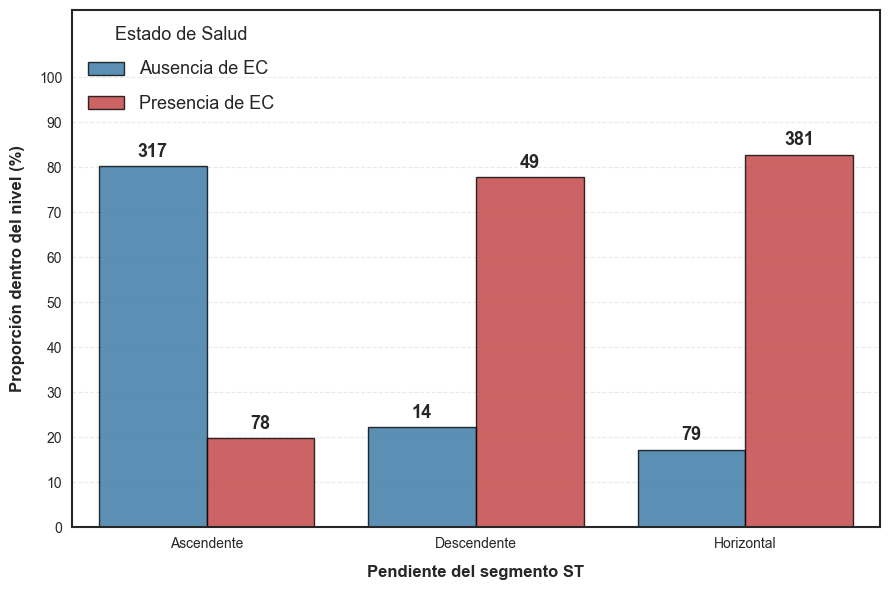

In [11]:
plot_categorical_association(
    df, 
    column='Contract', 
    target='HeartDisease',
    display_name='Pendiente del segmento ST', 
    level_mapping={'Flat': 'Horizontal', 'Up': 'Ascendente', 'Down': 'Descendente'},
    target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'},
    legend_title='Estado de Salud',
    legend_position='upper left', spanish = True
)

El análisis del Tipo de Dolor Torácico (`ChestPainType`), la segunda variable con mayor capacidad de discriminación, expone una dinámica clínica que subraya la importancia del diagnóstico diferencial. Al examinar la prevalencia de la enfermedad según la sintomatología, se constata que la angina atípica (ATA) y el dolor no anginoso (NAP) presentan una asociación comparativamente baja con la patología, superando el 80% y rondando el 65% de casos sanos en sus respectivas categorías. Por el contrario, la angina típica (TA) se comporta conforme a los modelos médicos tradicionales, al registrarse una mayor frecuencia relativa de la enfermedad frente a su ausencia. No obstante, el hallazgo empírico más crítico reside en el grupo asintomático (ASY), el cual concentra la mayor carga de morbilidad del conjunto de datos: cerca del 80% de los pacientes que no refieren dolor torácico convencional padece de hecho la enfermedad. Este perfil subraya el riesgo inherente de la isquemia silente en poblaciones de alto riesgo, donde la ausencia del síntoma clásico no constituye un criterio válido de exclusión clínica.


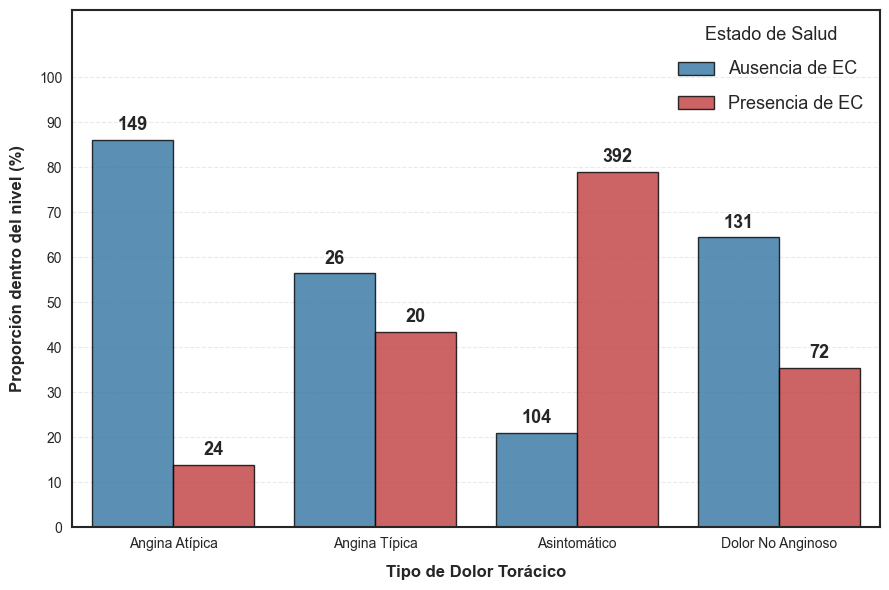

In [12]:
plot_categorical_association(
    df, 
    column='ChestPainType', 
    target='HeartDisease',
    display_name='Tipo de Dolor Torácico', 
    level_mapping={'TA': 'Angina Típica', 'ATA': 'Angina Atípica', 'NAP': 'Dolor No Anginoso','ASY': 'Asintomático'},
    target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'},
    legend_title='Estado de Salud',
    legend_position='upper right', spanish = True
)

La distribución de la Angina Inducida por el Ejercicio (`ExerciseAngina`), clasificada con un tamaño de efecto moderado en la estratificación previa, refuerza la prominencia de la respuesta del paciente bajo estrés fisiológico. El análisis de la prevalencia relativa revela que la ausencia de este síntoma está predominantemente asociada con un estado de salud cardiovascular, agrupando a un 65% de pacientes libres de la afección frente a un 35% con diagnóstico positivo. En marcada oposición, la aparición de dolor anginoso durante la prueba física opera como un fuerte indicador de compromiso coronario, con una prevalencia de enfermedad que se eleva drásticamente hasta alcanzar el 85% de los casos en este subgrupo. Esta acentuada disparidad subraya empíricamente que, si bien la ausencia de angina de esfuerzo no descarta completamente la afección, su manifestación clínica constituye una señal inequívoca de insuficiencia isquémica.


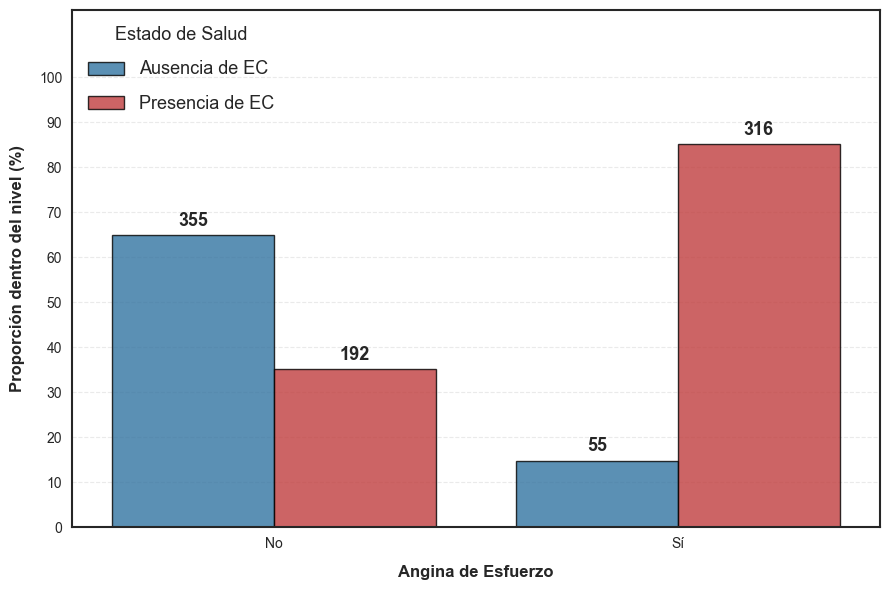

In [13]:
plot_categorical_association(
    df, 
    column='ExerciseAngina', 
    target='HeartDisease',
    display_name='Angina de Esfuerzo', 
    level_mapping={'Y': 'Sí', 'N': 'No'},
    target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'},
    legend_title='Estado de Salud',
    legend_position='upper left', spanish = True
)

Finalmente, la exploración del sexo refleja patrones epidemiológicos bien documentados en la literatura cardiovascular. La distribución proporcional intra-grupo evidencia una disparidad sustancial en la prevalencia de la enfermedad según el sexo biológico. En el grupo femenino, la ausencia de la patología es el escenario predominante, aglutinando aproximadamente al 75% de los casos frente a un 25% de incidencia positiva. En contraposición, la cohorte masculina muestra una inversión drástica de esta tendencia, con una prevalencia de la enfermedad cercana al 65%, superando ampliamente a los individuos sanos dentro de esta misma categoría. Esta divergencia clínica, que subraya una mayor vulnerabilidad masculina en este conjunto de datos, sugiere que el sexo opera como un factor de estratificación de riesgo pertinente, aun cuando no alcance el poder predictivo individual de los marcadores dinámicos de esfuerzo como `ST_Slope`.


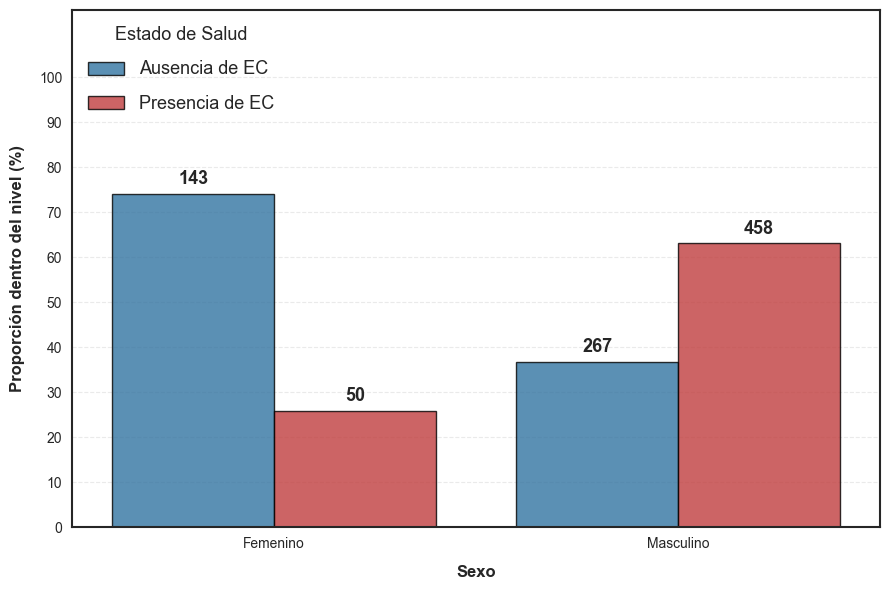

In [14]:
plot_categorical_association(
    df, 
    column='Sex', 
    target='HeartDisease',
    display_name='Sexo', 
    level_mapping={'M': 'Masculino', 'F': 'Femenino'},
    target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'},
    legend_title='Estado de Salud',
    legend_position='upper left', spanish = True
)

A modo de síntesis, la exploración desarrollada en esta sección aportó evidencia empírica de que la base de datos contiene indicadores categóricos altamente sólidos para la tarea de clasificación de los pacientes. El análisis de asociación y las distribuciones proporcionales permitieron constatar que el poder discriminativo del conjunto de datos se sustenta en una convergencia de factores de distinta naturaleza; destacando tanto marcadores clínicos directos como determinantes demográficos estructurales, ejemplificados por la influencia del sexo biológico. La comprobada robustez individual de estas variables establece una cimentación analítica rigurosa y pertinente para la futura estructuración de modelos predictivos.

##  Relación entre Variables Numéricas y la Variable Objetivo

Siguiendo la estructura analítica previa, esta sección aborda las Diferencias entre Grupos para las Variables Numéricas. Partiendo de la caracterización individual detallada en el análisis univariado, el enfoque transita ahora hacia la identificación de los patrones clínicos más determinantes. Para orientar este análisis y evitar una exploración redundante, se ejecutaron múltiples pruebas U de Mann-Whitney como filtro preliminar. El criterio rector para seleccionar qué distribuciones presentar no fue únicamente su significancia estadística, sino la magnitud de su tamaño del efecto (r de Rosenthal). Por consiguiente, el análisis visual y clínico se restringirá a los indicadores numéricos que exhiben una separación empírica sustancial.

In [44]:
 numeric_cols

['MonthlyCharges', 'TotalCharges']

In [43]:
analyze_continuous_association(df, target = 'Churn', numeric_features = numeric_cols,
    correction_method = "holm", spanish = True, group_names = ("Sin EC", "Con EC")) 

Insufficient data for the specified numeric variables.


El escrutinio de las variables numéricas mediante la prueba U de Mann-Whitney revela que ninguna de las características continuas alcanza un tamaño de efecto catalogado como grande. No obstante, el análisis identifica marcadores con un poder discriminativo moderado que resultan clínicamente relevantes. La frecuencia cardíaca máxima (`MaxHR`) y la depresión del segmento ST (`Oldpeak`) se posicionan como las variables con mayor capacidad de separación, ambas con un efecto mediano ($r = 0.40$). Esto evidencia que sus distribuciones de probabilidad global difieren de manera sustancial y sistemática entre los pacientes sanos y aquellos con la patología. Adicionalmente, el comportamiento heterocedástico observado en ambos casos indica que la dispersión intrínseca de estos parámetros biológicos se altera de forma asimétrica ante la presencia de la enfermedad.

Por el contrario, el resto de los parámetros evaluados mostraron una divergencia poblacional estadísticamente débil. La edad (`Age`, $r = 0.28$) y la presión arterial en reposo (`RestingBP`, $r = 0.11$) apenas alcanzan tamaños de efecto pequeños, lo que sugiere una superposición considerable en sus distribuciones de probabilidad entre ambos grupos de diagnóstico. Asimismo, las discrepancias globales en la distribución del colesterol (`Cholesterol`) ostentan el tamaño de efecto más bajo del conjunto ($r = 0.05$), indicando que, al menos de forma aislada e incondicional, este biomarcador no proporciona una frontera analítica clara para distinguir el estado de salud cardiovascular de los pacientes.

:::{admonition} Nota Metodológica: Coeficiente r de Rosenthal
:class: note

Para cuantificar la magnitud de las diferencias entre grupos analizados por medio de la prueba de rangos de Mann-Whitney, se calcula el coeficiente $r$ de Rosenthal. A diferencia de la diferencia de medias simple, este coeficiente proporciona una medida del tamaño del efecto que es independiente del tamaño de la muestra y comparable con otros estudios. La fórmula matemática para su cálculo a partir del estadístico $Z$ es:

$$r = \frac{|Z|}{\sqrt{n}}$$

Donde:

* $Z$: Es el valor crítico estandarizado obtenido de la prueba de Mann-Whitney.
  
* $n$: Es el número total de observaciones en la muestra.

La interpretación de la fuerza de la asociación sigue los umbrales propuestos por [Cohen (2013)](https://doi.org/10.4324/9780203771587) para coeficientes de correlación en ciencias del comportamiento, permitiendo categorizar el impacto de la variable en la diferenciación de los grupos de la siguiente manera:

* Pequeño: $0.10 \le r < 0.30$
  
* Mediano: $0.30 \le r < 0.50$

* Grande: $r \ge 0.50$

Este enfoque permite identificar qué variables continuas tienen una relevancia clínica real más allá de la significancia estadística, facilitando la comparación directa con el análisis de la V de Cramer realizado para las variables categóricas.

:::

La visualización de la Frecuencia Cardíaca Máxima Alcanzada (`MaxHR`), clasificada con un tamaño de efecto moderado en la estratificación previa, refuerza la prominencia de la capacidad de respuesta cardiovascular del paciente bajo estrés fisiológico. El análisis de las distribuciones de densidad revela que alcanzar frecuencias cardíacas elevadas durante el ejercicio está predominantemente asociado con un estado de salud, donde la curva de los pacientes libres de la afección (color azul) se concentra visiblemente hacia el extremo superior del espectro, con un pico de densidad alrededor de los 160 latidos por minuto. En marcada oposición, la incapacidad de elevar sustancialmente el ritmo cardíaco opera como un fuerte indicador de compromiso coronario. La distribución de los pacientes con diagnóstico positivo (color rojo) se encuentra francamente desplazada hacia la izquierda, concentrando su mayor densidad cerca de los 120 latidos por minuto. Esta acentuada disparidad subraya empíricamente que, si bien alcanzar una frecuencia alta no inmuniza contra la afección, la limitación cronotrópica durante la prueba física constituye un marcador claro de insuficiencia isquémica.


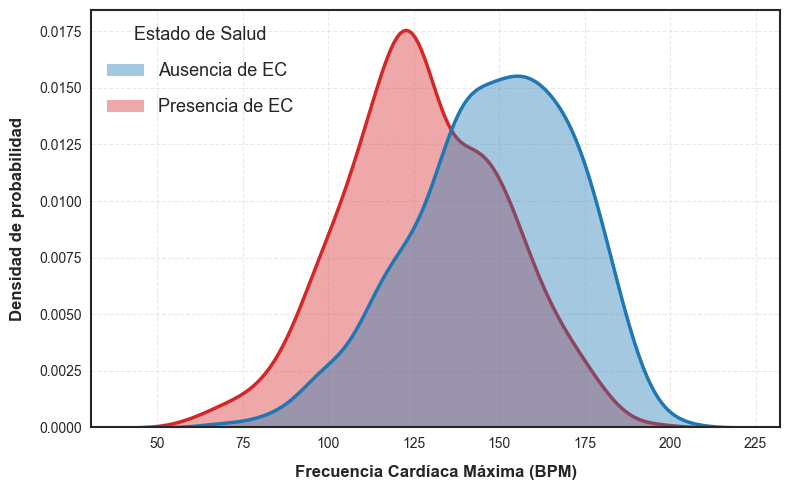

In [7]:
plot_numeric_distribution(df, 'MaxHR', display_name='Frecuencia Cardíaca Máxima (BPM)',
                          legend_position='upper left', legend_title='Estado de Salud',
                          target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'}, spanish = True)

Por otro lado, la evaluación de la depresión del segmento ST inducida por el ejercicio (`Oldpeak`), que también exhibió un tamaño de efecto moderado en la caracterización estadística, expone una dinámica clínica que subraya la relevancia de las alteraciones electrocardiográficas. El análisis de las densidades probabilísticas revela que la ausencia de depresión significativa (valores cercanos a 0 mm) está predominantemente asociada con un estado de salud cardiovascular, concentrando la mayor parte de los pacientes libres de la afección en torno al origen del eje. En constraste, la manifestación de valores elevados de `Oldpeak` durante la prueba física opera como un fuerte indicador de compromiso coronario. La distribución de los pacientes con diagnóstico positivo se encuentra drásticamente desplazada hacia la derecha, exhibiendo una cola pesada que documenta la prevalencia de la enfermedad en niveles superiores a 1 mm. Estas diferenicas sugieren que, si bien una ligera variación en el segmento ST no confirma de forma absoluta la patología, una depresión profunda constituye un marcador crítico de la presencia de enfermedad cardíaca.


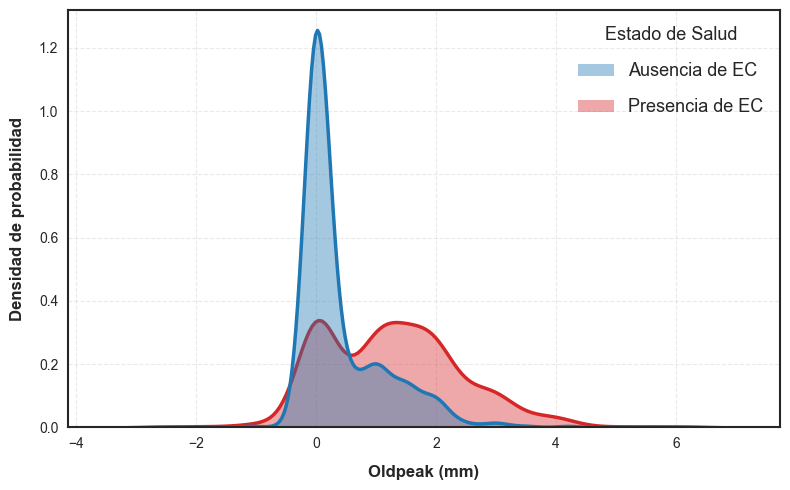

In [8]:
plot_numeric_distribution(df, 'Oldpeak', display_name='Oldpeak (mm)',
                          legend_position='upper right',
                          legend_title='Estado de Salud',
                          target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'}, spanish = True)

Finalmente, el análisis de la edad, que presentó un tamaño de efecto pequeño en la fase de filtrado, permite observar la transición del riesgo cardiovascular a través del ciclo vital. El examen de las densidades probabilísticas revela que los pacientes libres de la afección tienden a concentrarse en rangos de edad más jóvenes, con un pico de densidad situado cerca de los 45 años. En contraste, la distribución de los pacientes con diagnóstico positivo muestra un desplazamiento progresivo hacia la derecha, alcanzando su mayor concentración alrededor de los 58 años. Esta divergencia sugiere que, si bien la enfermedad no es exclusiva de la madurez, la probabilidad de presentar un compromiso coronario aumenta sistemáticamente con el envejecimiento, reflejando el carácter acumulativo de los factores de riesgo biológicos. No obstante, la amplia superposición entre ambas curvas confirma que la edad, por sí misma, posee una capacidad discriminativa inferior a la de los marcadores dinámicos obtenidos bajo estrés físico.


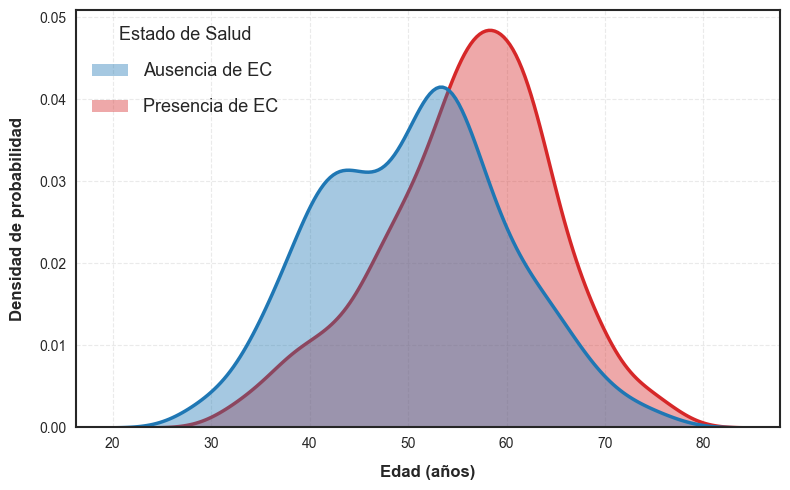

In [9]:
plot_numeric_distribution(df, 'Age', display_name='Edad (años)',
                          legend_position='upper left',
                          legend_title='Estado de Salud',
                          target_mapping={'0': 'Ausencia de EC', '1': 'Presencia de EC'}, spanish = True)

# Análisis de Dependencia

En esta sección se evalúa la relación estadística entre las variables del conjunto de datos y su capacidad discriminativa respecto a la presencia de enfermedad cardiovascular. Dado que los análisis previos sugieren distribuciones no gaussianas y relaciones potencialmente no lineales, se emplea inicialmente la correlación de rangos de Spearman para identificar asociaciones monótonas entre pares de variables continuas. Posteriormente, para capturar dependencias de orden superior y manejar la naturaleza mixta (numérica y categórica) del dataset, se implementa un análisis de Información Mutua (MI) en conjunto con el algoritmo de Mínima Redundancia y Máxima Relevancia (mRMR). Este enfoque híbrido permite no solo cuantificar la relevancia individual de cada atributo, sino también identificar el subconjunto de variables que aporta información única y parsimoniosa para el modelado predictivo.

A continuación, se presenta la matriz de correlación de Spearman, la cual permite visualizar la estructura de interdependencia monotónica de las variables continuas en el conjunto de datos:


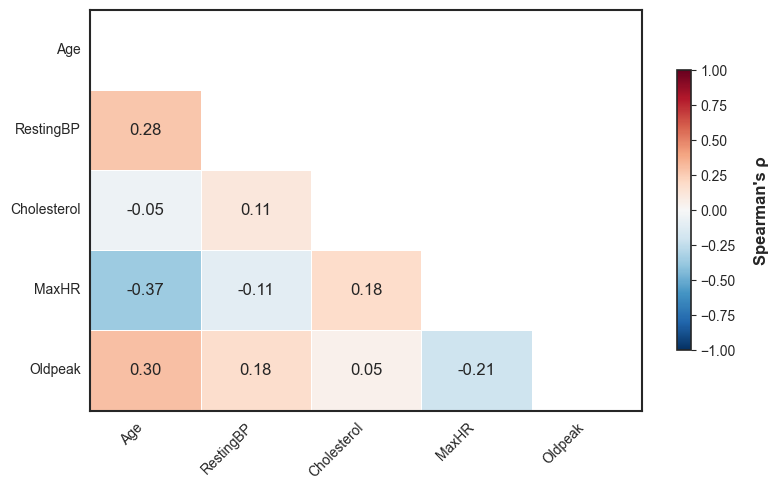

In [7]:
plot_spearman_heatmap(df, numeric_cols, annot_size = 12)

La inspección de la matriz de correlación revela una marcada independencia estocástica entre la mayoría de los atributos continuos del conjunto de datos, con coeficientes que se mantienen predominantemente en rangos de magnitud baja ($|r_s| < 0.40$). Esta estructura de datos sugiere una ausencia de redundancia monotónica, lo cual implica que no existen transformaciones no lineales, siempre que preserven el orden, de una variable que puedan explicar satisfactoriamente el comportamiento de otra. Este fenómeno es particularmente evidente en variables críticas como el colesterol y la presión arterial en reposo, cuya correlación con el resto de predictores es casi nula, exceptuando la asociación negativa moderada entre la edad y la frecuencia cardíaca máxima, la cual es consistente con la reducción fisiológica de la capacidad cronotrópica durante el envejecimiento. Desde la perspectiva del modelado, esta cuasi-ortogonalidad de los atributos continuos es altamente beneficiosa para garantizar la estabilidad de los estimadores y evitar conflictos de multicolinealidad en modelos de aprendizaje supervisado.

:::{admonition} Nota Metodológica: Información Mutua (MI) y Algoritmo mRMR
:class: note

Para evaluar la relevancia de los atributos en este conjunto de datos mixto, se utiliza la Información Mutua (MI; [Shannon, 1948](10.1002/j.1538-7305.1948.tb01338.x)) en lugar de coeficientes tradicionales como la correlación punto-biseral. A diferencia de esta última, que asume una relación lineal y normalidad en las distribuciones, la MI es una medida no paramétrica basada en la Entropía de Shannon que permite detectar cualquier tipo de dependencia estadística, incluyendo interacciones complejas y no lineales. Matemáticamente, la MI entre una variable $X$ y el objetivo $Y$ se define como:

$$MI(X; Y) = H(X) + H(Y) - H(X, Y)$$

Donde $H(\cdot)$ representa la entropía, una medida de la incertidumbre o el contenido de información de las variables.

Para refinar este análisis, se aplicó el criterio de Mínima Redundancia y Máxima Relevancia (mRMR; [Peng et al, 2005](10.1109/TPAMI.2005.159)). Es importante destacar que, en esta etapa, el mRMR no se utiliza como un método de selección definitiva de características (*Feature Selection*), sino como una medida alternativa de importancia que permite ponderar la contribución individual de cada variable frente a su redundancia con las demás. El ranking se determina mediante la optimización de la diferencia entre la relevancia y la redundancia media:

$$f_{mRMR}(X_i) = \max \left[ MI(X_i; Y) - \frac{1}{|S|} \sum_{X_j \in S} MI(X_i; X_j) \right]$$

Donde:

* $S$: Es el conjunto de características ya evaluadas en el ranking.
  
* $MI(X_i; Y)$: Representa la relevancia de la característica respecto al objetivo (enfermedad cardíaca).

* $\frac{1}{|S|} \sum MI(X_i; X_j)$: Representa la redundancia media de la candidata con las variables ya posicionadas.

Este enfoque permite identificar variables que, aunque presenten un tamaño del efecto pequeño en análisis bivariados, poseen un alto valor informativo al no estar correlacionadas con el resto del sistema.
:::

Por otro lado, los resultados del algoritmo mRMR confirman la alta capacidad discriminativa de variables identificadas previamente en los análisis bivariados, tales como `Oldpeak` y `MaxHR`, las cuales presentan las magnitudes de Información Mutua (MI) más elevadas, consolidándose como los predictores principales de la enfermedad cardiovascular. No obstante, el valor diferencial de este enfoque radica en la observación de atributos como `FastingBS`; si bien esta presenta efectos pequeños en los análisis previos y no posee una relevancia individual dominante en términos de MI, se posiciona en niveles superiores del ranking debido a que aporta información complementaria que no está presente en el resto de los predictores. Este comportamiento permite identificar *a priori* aquellas características que, al ofrecer una perspectiva única del fenómeno, enriquecen el conocimiento sobre el dataset sin introducir datos repetitivos. Al integrar estos hallazgos con la baja correlación de rangos observada anteriormente, es de esperar que la relación entre los atributos y la patología esté mediada por efectos no lineales e interacciones complejas, factores que deberán ser considerados prioritariamente al seleccionar y ajustar los algortimos de clasificación.

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# df = df.drop(columns=['customerID'])
df_encoded = df.copy()

replace_dict = {'No internet service': 'No','No phone service': 'No'}
df_encoded = df_encoded.replace(replace_dict)


binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

df_encoded['gender'] = df_encoded['gender'].map({'Female': 0,'Male': 1})

yes_no_map = {'No': 0,'Yes': 1}

for col in binary_cols:
    if col != 'gender' and col != 'PaperlessBilling':
        df_encoded[col] = df_encoded[col].map(yes_no_map)

contract_map = {'Month-to-month': 0,'One year': 1,'Two year': 2}
df_encoded['Contract'] = df_encoded['Contract'].map(contract_map)
df_encoded = pd.get_dummies(df_encoded, columns=['InternetService'], drop_first=True, dtype=int)
df_encoded = pd.get_dummies(df_encoded,columns=['PaymentMethod'],drop_first=True, dtype=int)


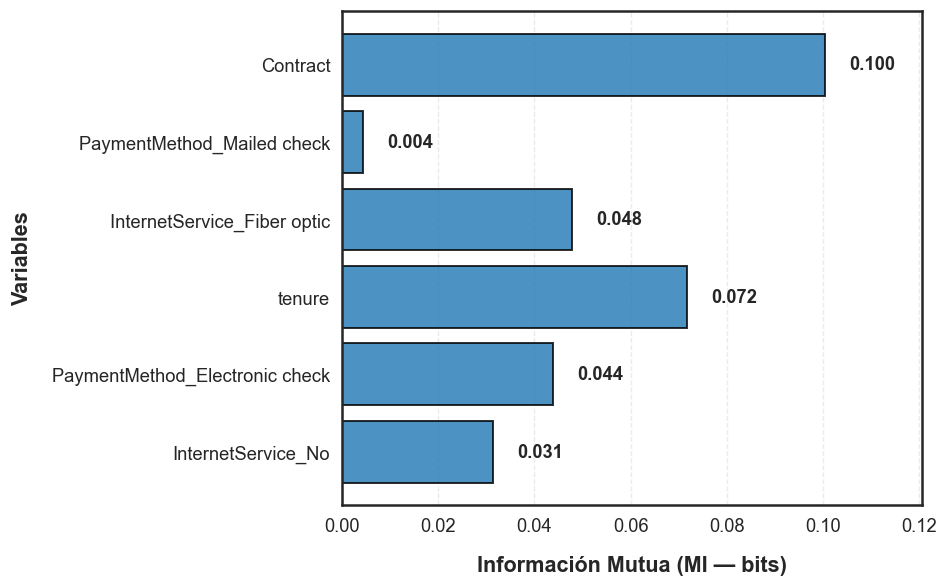

In [26]:
plot_mrmr_importance(df_encoded, figsize = (8, 5), target_col = "Churn", top_k = 6)

# Exportación del Conjunto de Datos Final

Tras concluir la fase de análisis exploratorio, se procede con la exportación del conjunto de datos final, el cual servirá como insumo base para la etapa de modelado. Es importante precisar que, en esta instancia, el tratamiento de los datos se limitó exclusivamente a la inconsistencias de registro, preservando la naturaleza original de la información. Otros procesos críticos de ingeniería de características, tales como la codificación de variables categóricas o la imputación de datos, se han reservado deliberadamente para la fase de construcción de modelos; esta decisión técnica busca blindar el experimento contra la fuga de información (*data leakage*), asegurando que cualquier transformación basada en la distribución de los datos se ejecute estrictamente dentro de los protocolos de validación y entrenamiento de los clasificadores.

In [15]:
df_export = df.copy()
output_path = Path("../data/telco_churn_preprocessed.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_export.to_parquet(output_path, index=False, engine="pyarrow")